## *Equipe*
## Victor 
## Rodrigo 
## Ex.integrante: Kamila

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

2025-01-22 17:43:08.497691: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-22 17:43:08.507567: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737582188.519629   25601 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737582188.523072   25601 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-22 17:43:08.535429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
path= '/home/turma02/Área de trabalho/folhasamostras/classe1/'

In [3]:
num_classes = 2

In [4]:
modelo_base = ResNet50(weights='imagenet', include_top = False, input_shape = (224, 224, 3))

2025-01-22 17:43:11.888808: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-01-22 17:43:11.888828: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: suporte-Legion-Slim-5-16IRH8
2025-01-22 17:43:11.888831: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: suporte-Legion-Slim-5-16IRH8
2025-01-22 17:43:11.888967: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 550.120.0
2025-01-22 17:43:11.888977: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 550.120.0
2025-01-22 17:43:11.888980: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 550.120.0


In [5]:
modelo_novo = modelo_base.output
modelo_novo = GlobalAveragePooling2D()(modelo_novo)
modelo_novo = Dense(1024, activation = 'relu')(modelo_novo)
predicoes = Dense(num_classes, activation = 'softmax')(modelo_novo)

In [6]:
modelo = Model(inputs = modelo_base.input, outputs = predicoes)

In [7]:
for layer in modelo_base.layers:
    layer.trainable = False

In [8]:
modelo.compile(optimizer=Adam(learning_rate=0.001),
               loss = 'categorical_crossentropy',
               metrics=['accuracy'])

## Treino

In [9]:
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

In [10]:
validation_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

In [11]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(path, 'Train'),
    target_size = (224, 224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 61 images belonging to 2 classes.


## Validação

In [12]:
validation_generator = validation_datagen.flow_from_directory(
    os.path.join(path, 'Test'),
    target_size = (224, 224),
    batch_size = 10,
    class_mode = 'categorical'
)

Found 12 images belonging to 2 classes.


In [13]:
modelo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,687,938 (97.99 MB)

 Trainable params: 2,100,226 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img

In [15]:
class_labels = list(validation_generator.class_indices.keys())
def classifica_imagem(imagem):
    img = load_img(imagem, target_size = (224, 224))
    img_ = image.img_to_array(img)
    img_ = np.expand_dims(img_, axis = 0)
    img_ = preprocess_input(img_)
    preds = modelo.predict(img_)
    classe_predita = np.argmax(preds, axis = 1)[0]
    rotulo_predito = class_labels[classe_predita]
    print(f"Classe predita: {rotulo_predito} - {preds[0][classe_predita]:.4}")
    

In [16]:
history = modelo.fit(
    train_generator,
    steps_per_epoch = train_generator.samples // train_generator.batch_size,
    validation_data = validation_generator,
    validation_steps = validation_generator.samples // validation_generator.batch_size,
    epochs = 20
)

/home/turma02/anaconda3/envs/turma02/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 597ms/step - accuracy: 0.4721 - loss: 2.1224 - val_accuracy: 1.0000 - val_loss: 0.1552
Epoch 2/20
1/6 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - accuracy: 0.5000 - loss: 1.8542

/home/turma02/anaconda3/envs/turma02/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.5000 - loss: 1.8542 - val_accuracy: 1.0000 - val_loss: 0.0261
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 373ms/step - accuracy: 0.9311 - loss: 0.2673 - val_accuracy: 1.0000 - val_loss: 0.0639
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9000 - loss: 1.0378 - val_accuracy: 1.0000 - val_loss: 0.0133
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 0.9254 - loss: 0.1850 - val_accuracy: 1.0000 - val_loss: 0.0077
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9000 - loss: 1.1450 - val_accuracy: 1.0000 - val_loss: 0.0250
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 394ms/step - accuracy: 0.8858 - loss: 0.2562 - val_accuracy: 1.0000 - val_loss: 9.1747e-04
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 1.0000 - loss: 0.0936 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.9294 - loss: 0.2375 - val_accuracy: 1.0000 - val_loss: 0.0054
Epo

In [17]:
modelo.save('resnet_10_epoch_folhasamostras.keras')

In [30]:
imagem = path + 'amostra4.jpeg'

In [31]:
path

'/home/turma02/Área de trabalho/folhasamostras/classe1/'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Classe predita: NDefeituosa - 0.9389


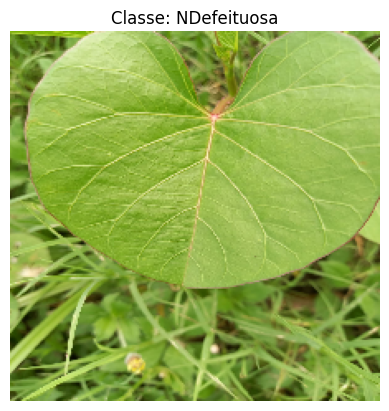

In [32]:
class_labels = list(validation_generator.class_indices.keys())

def classifica_imagem(imagem):
    
    img = load_img(imagem, target_size=(224, 224))
    img_ = image.img_to_array(img)
    img_ = np.expand_dims(img_, axis=0)
    img_ = preprocess_input(img_)

    preds = modelo.predict(img_)
    classe_predita = np.argmax(preds, axis=1)[0]
    rotulo_predito = class_labels[classe_predita]

    print(f"Classe predita: {rotulo_predito} - {preds[0][classe_predita]:.4f}")

    plt.imshow(img)
    plt.title(f"Classe: {rotulo_predito}")
    plt.axis("off")
    plt.show()

classifica_imagem(imagem)

## Extração de características usando o modelo ResNet50

In [33]:
train_features = modelo_base.predict(train_generator)
train_labels = train_generator.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step


In [34]:
test_features = modelo_base.predict(validation_generator)
test_labels = validation_generator.classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step 


## Utilize o PCA e teste 3 classificadores tradicionais para indicar o melhor resultado: SVM, Random Forest e Logistic Regression.

In [35]:
n_components = min(50, train_features.shape[0])  # 50 ou o número de amostras (48)
pca = PCA(n_components=n_components)
train_features_pca = pca.fit_transform(train_features.reshape(train_features.shape[0], -1))
test_features_pca = pca.transform(test_features.reshape(test_features.shape[0], -1))

In [36]:
classifiers = {
    "SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}
for name, clf in classifiers.items():
    clf.fit(train_features_pca, train_labels)
    preds = clf.predict(test_features_pca)
    results[name] = {
        "Classification Report": classification_report(test_labels, preds, target_names=class_labels),
        "Confusion Matrix": confusion_matrix(test_labels, preds)
    }

/home/turma02/anaconda3/envs/turma02/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/turma02/anaconda3/envs/turma02/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/turma02/anaconda3/envs/turma02/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

## Indique o que obteve o melhor resultado e comprove com a comparação dos métodos (matriz de confusão e relatório de classificação).


SVM Results:
              precision    recall  f1-score   support

  Defeituosa       0.44      0.67      0.53         6
 NDefeituosa       0.33      0.17      0.22         6

    accuracy                           0.42        12
   macro avg       0.39      0.42      0.38        12
weighted avg       0.39      0.42      0.38        12



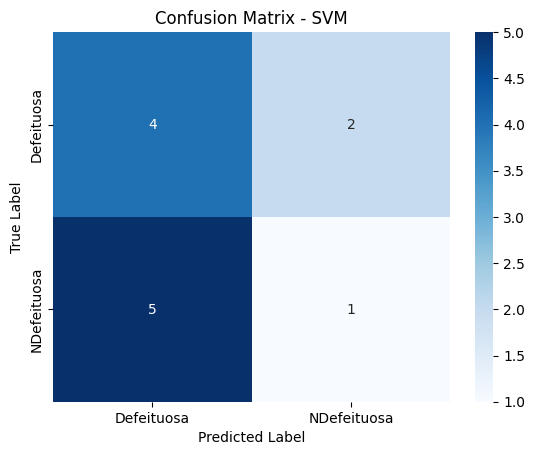


Random Forest Results:
              precision    recall  f1-score   support

  Defeituosa       0.00      0.00      0.00         6
 NDefeituosa       0.50      1.00      0.67         6

    accuracy                           0.50        12
   macro avg       0.25      0.50      0.33        12
weighted avg       0.25      0.50      0.33        12



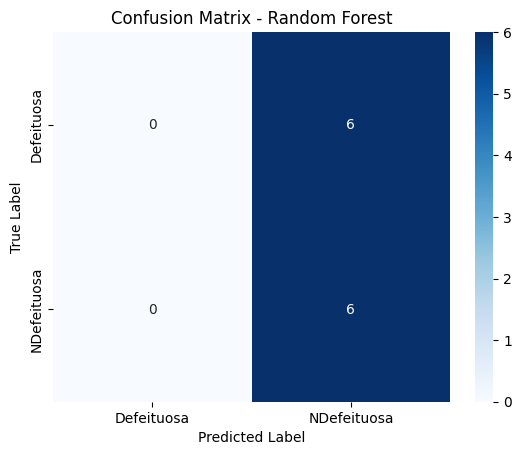


Logistic Regression Results:
              precision    recall  f1-score   support

  Defeituosa       0.29      0.33      0.31         6
 NDefeituosa       0.20      0.17      0.18         6

    accuracy                           0.25        12
   macro avg       0.24      0.25      0.24        12
weighted avg       0.24      0.25      0.24        12



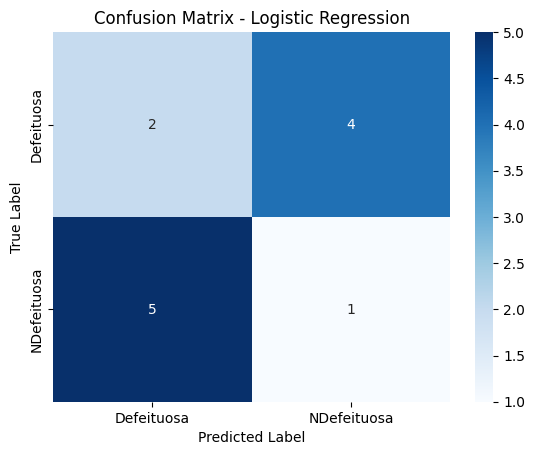

In [37]:
for name, result in results.items():
    print(f"\n{name} Results:")
    print(result["Classification Report"])
    sns.heatmap(result["Confusion Matrix"], annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()